## 0. Setup

### 0.1. Libraries and Helper Functions

Moral stores: https://huggingface.co/datasets/demelin/moral_stories/viewer/cls-action+context+consequence-norm_distance?row=1

In [ ]:
!pip install -q transformers
!pip install -q torchinfo
!pip install -q datasets
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==1

Now we are ready to do the imports.

In [ ]:
#@title Imports

import numpy as np

import transformers
import evaluate

from datasets import load_dataset
from torchinfo import summary

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

### 0.2 Data Acquisition


We will use the Moral Stores dataset delivered as part of the TensorFlow-datasets library, and split into training and test sets.

In [ ]:
from datasets import load_dataset

# Load the dataset
moral_dataset = load_dataset("demelin/moral_stories", "cls-action+context+consequence-norm_distance")

# Select only the first 4000 for training and first 1000 for testing
moral_train_dataset = moral_dataset['train'].shuffle().select(range(20000))
moral_dev_dataset = moral_dataset['test'].shuffle().select(range(2000))


README.md:   0%|          | 0.00/12.0k [00:00<?, ?B/s]

moral_stories.py:   0%|          | 0.00/11.4k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/3.70M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# the size of moral_dataset

len(moral_dataset['train']), len(moral_dataset['test'])


(20000, 2000)

It is always highly recommended to look at the data. What do the records look like? Are they clean or do they contain a lot of cruft (potential noise)?

In [ ]:
# Data labels
moral_train_dataset

Dataset({
    features: ['ID', 'norm', 'situation', 'intention', 'moral_action', 'moral_consequence', 'immoral_action', 'immoral_consequence', 'label'],
    num_rows: 20000
})

In [ ]:
for i in range(4):
  print(moral_train_dataset['situation'][i])
  print(moral_train_dataset['moral_action'][i])
  print(moral_train_dataset['immoral_action'][i])
  print(moral_train_dataset['label'][i])
  print()

Gary runs a farm and employs outside help to bring in the harvest.
Gary pays his helpers and files the tax paperwork for their pay.
not specified
1

Roger is in his garage finishing up an oil change for his truck.
not specified
Roger decides to dump the used oil in his backyard.
0

Ann promised Marie they would go out to lunch together, but Ann doesn't feel like going out.
Ann decides to go anyway since she made a promise and Marie was looking forward to it.
not specified
1

Several of James coworker's have been diagnosed with COVID, but James has to work with them on a  work project.
not specified
James works close to them without a mask and protective gear.
0



### EDA

In [ ]:
moral_train_dataset.column_names

['ID',
 'norm',
 'situation',
 'intention',
 'moral_action',
 'moral_consequence',
 'immoral_action',
 'immoral_consequence',
 'label']

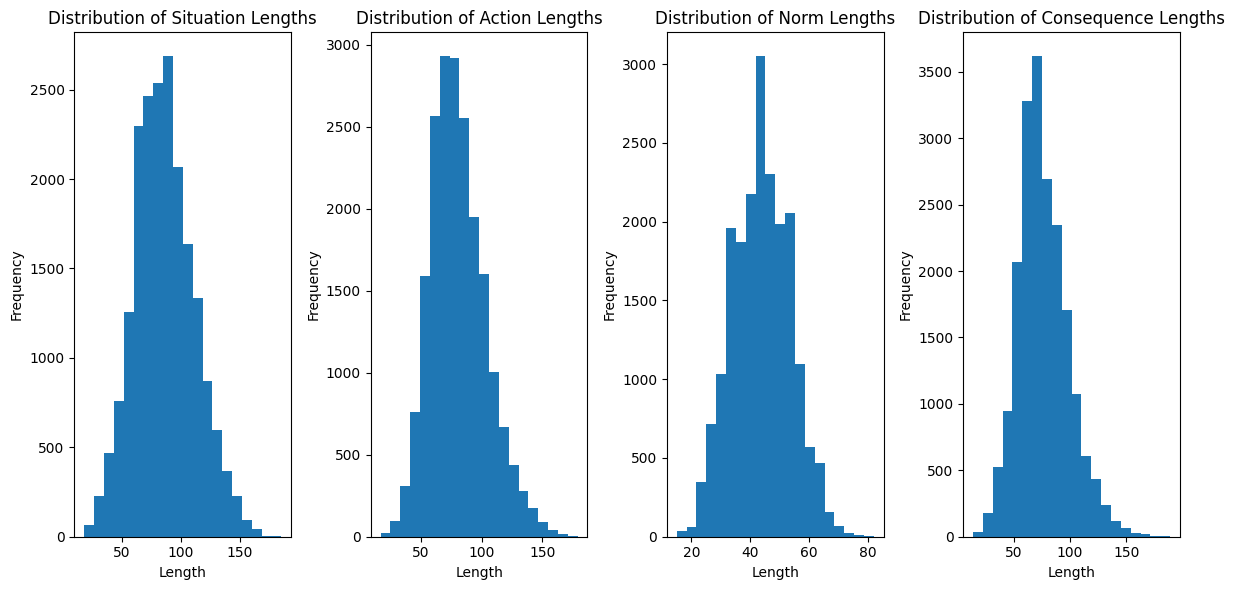

In [ ]:
import matplotlib.pyplot as plt

situation_lengths = [len(text) for text in moral_train_dataset['situation']]
norm_lengths = [len(text) for text in moral_train_dataset['norm']]

moral_action_lengths = []
for action in moral_train_dataset['moral_action']:
  if action != 'not specified':
    moral_action_lengths.append(len(action))
immoral_action_lengths = []
for action in moral_train_dataset['immoral_action']:
  if action != 'not specified':
    immoral_action_lengths.append(len(action))
action_lengths = moral_action_lengths + immoral_action_lengths

moral_consequence_lengths = []
for consequence in moral_train_dataset['moral_consequence']:
  if consequence != 'not specified':
    moral_consequence_lengths.append(len(consequence))
immoral_consequence_lengths = []
for consequence in moral_train_dataset['immoral_consequence']:
  if consequence != 'not specified':
    immoral_consequence_lengths.append(len(consequence))
consequence_lengths = moral_consequence_lengths + immoral_consequence_lengths

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.hist(situation_lengths, bins=20)
plt.title('Distribution of Situation Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 2)
plt.hist(action_lengths, bins=20)
plt.title('Distribution of Action Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 3)
plt.hist(norm_lengths, bins=20)
plt.title('Distribution of Norm Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 4)
plt.hist(consequence_lengths, bins=20)
plt.title('Distribution of Consequence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

print(f"The mean of situation_lengths is: {np.mean(situation_lengths)}")
print(f"The mean of moral_action_lengths (excluding 0) is: {np.mean(moral_action_lengths)}")
print(f"The mean of immoral_action_lengths (excluding 0) is: {np.mean(immoral_action_lengths)}")
print(f"The mean of norm_lengths is: {np.mean(norm_lengths)}")
print(f"The mean of moral_consequence_lengths (excluding 0) is: {np.mean(moral_consequence_lengths)}")
print(f"The mean of immoral_consequence_lengths (excluding 0) is: {np.mean(immoral_consequence_lengths)}")


The mean of situation_lengths is: 85.9598
The mean of moral_action_lengths (excluding 0) is: 80.656
The mean of immoral_action_lengths (excluding 0) is: 80.8544
The mean of norm_lengths is: 43.8687
The mean of moral_consequence_lengths (excluding 0) is: 75.575
The mean of immoral_consequence_lengths (excluding 0) is: 77.0968


### 0.3. Data Preparation

In [ ]:
def preprocess_moral(data, tokenizer):
    merged_texts = []

    for moral, immoral, norm, mo_cons, im_cons in zip(data['moral_action'], data['immoral_action'], data['norm'], data['moral_consequence'], data['immoral_consequence']):
        # Ignore "not specified" values for moral and immoral actions
        if moral.lower() == "not specified":
            action_text = immoral+" "+im_cons+" "+norm
        elif immoral.lower() == "not specified":
            action_text = moral+" "+mo_cons+" "+norm
        else:
            action_text = f"{moral} {immoral}"  # Merge both sentences

        # Add the [CLS] token at the beginning, followed by situation, norm, and action_text, all separated by [SEP]
        #action_text = f"[CLS] {action_text} [SEP]"

        merged_texts.append(action_text)  # Store the merged text

    # Tokenize the batch of merged sentences
    encoded = tokenizer.batch_encode_plus(
        merged_texts,
        max_length=MAX_SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "token_type_ids": encoded["token_type_ids"]
    }


## Check tokenizers

In [ ]:
MAX_SEQUENCE_LENGTH = 128*2

In [ ]:
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
roberta_model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
roberta_tokenizer(moral_train_dataset['moral_action'][2],
               max_length=MAX_SEQUENCE_LENGTH,
               truncation=True,
               padding='max_length',
               return_tensors='pt')

{'input_ids': tensor([[    0, 20767, 11703,     7,   213,  6992,   187,    79,   156,    10,
          4198,     8,  9340,    21,   546,   556,     7,    24,     4,     2,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,  

# Prepare for training

In [ ]:
# Load accuracy and F1 metrics
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)  # Convert logits to class predictions

    # Compute accuracy
    acc = metric_acc.compute(predictions=predictions, references=labels)

    # Compute F1-score (weighted to account for class imbalance)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")

    # Return both metrics
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}


In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        #output_dir="./results",
        output_dir="/content/drive/My Drive/roberta_large_action_consequence",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()


## Model Training

In [ ]:
"""
Show the output from training roberta-base on the Moral reviews dataset.
"""

# Use RoBERTa-base
model_checkpoint_name = "roberta-base"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.112100,0.110427,0.974500,0.974499
2,0.060900,0.087532,0.984000,0.984000
3,0.023000,0.107584,0.982500,0.982500


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
Show the output from training roberta-large on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "roberta-large"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.098300,0.077960,0.986000,0.986000
2,0.039100,0.065480,0.986500,0.986500
3,0.007800,0.068869,0.989500,0.989500


In [ ]:
"""
Show the output from training roberta-base-sentiment-latest on the Moral reviews dataset.
"""

model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.122800,0.094038,0.979500,0.979500
2,0.044300,0.097843,0.981500,0.981500
3,0.021300,0.117875,0.981000,0.981000


In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

model_checkpoint_name = "bert-base-cased"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.132700,0.101584,0.971000,0.971000
2,0.065500,0.109941,0.976000,0.976000
3,0.031000,0.125184,0.977500,0.977500


In [ ]:
"""
Show the output from training BERT-large-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "bert-large-cased"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.105200,0.085764,0.980000,0.980000
2,0.034800,0.122253,0.978500,0.978499
3,0.012500,0.128368,0.978000,0.978000


In [ ]:
"""
Show the output from training microsoft/deberta-v3-base on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "microsoft/deberta-v3-base"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.070700,0.069280,0.983000,0.983000
2,0.015500,0.076427,0.987000,0.987000
3,0.011800,0.080481,0.988000,0.988000


In [ ]:
"""
Show the output from training google/t5-v1_1-base on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "google/t5-v1_1-base"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 48.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 22.12 MiB is free. Process 9257 has 14.72 GiB memory in use. Of the allocated memory 14.07 GiB is allocated by PyTorch, and 527.59 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)